# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
import plotly.figure_factory as ff

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
#seu código aqui
X_test = pd.read_csv(r"Bases\X_test.csv", delimiter=',')
X_train = pd.read_csv(r"Bases\X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv(r"Bases\y_test.csv", delimiter=',')
y_train = pd.read_csv(r"Bases\y_train_balanced.csv", delimiter=',')

In [3]:
X_test

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,25,55000.0,0,0,1,1,1
1,48,87500.0,1,0,2,0,0
2,26,55000.0,1,0,1,0,0
3,39,62500.0,2,0,1,0,0
4,35,90000.0,1,0,2,0,0
5,25,55000.0,0,0,1,1,1
6,48,82500.0,1,0,2,0,0
7,48,82500.0,1,0,2,0,0
8,36,95000.0,2,0,4,0,0
9,37,95000.0,1,0,3,0,0


In [4]:
y_test

,CreditScore Encoded
0,0
1,1
2,0
3,1
4,1
5,0
6,1
7,1
8,1
9,1


In [5]:
X_train

,Age,Income,Number of Children,Gender Encoded,Education Encoded,Marital Encoded,HomeOwnership Encoded
0,26,45000.000000,0,0,0,1,1
1,29,27500.000000,0,0,3,1,1
2,25,62500.000000,0,0,1,1,1
3,29,68000.000000,2,0,2,0,0
4,31,65000.000000,0,1,1,1,1
...,...,...,...,...,...,...,...
247,27,36803.652916,0,0,2,1,1
248,27,37500.000000,0,0,3,1,1
249,28,29946.263487,0,0,1,1,1
250,27,35412.944984,0,0,1,1,1


In [6]:
y_train

,CreditScore Encoded
0,0
1,2
2,0
3,0
4,0
...,...
247,2
248,2
249,2
250,2


In [7]:
# Verificando o balanceamento das classes
# Contando número de exemplos em y_train
y_train_counts = y_train.value_counts()
print("Contagem de exemplos em y_train:")
print(y_train_counts)

# COntando númeroi de exemplos em y_test
y_test_conts = y_test.value_counts()
print("Contagem de exemplos em y_test:")
print(y_test_conts)

Contagem de exemplos em y_train:
CreditScore Encoded
0                      84
1                      84
2                      84
Name: count, dtype: int64
Contagem de exemplos em y_test:
CreditScore Encoded
1                      29
0                       6
2                       6
Name: count, dtype: int64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [8]:
#seu código aqui
# Criando instância do Classificador Naive Bayes
gnb = GaussianNB()
# treinamento do classificador usando dos dados de treinamento
gnb.fit(X_train, y_train)

c:\Users\rodri\dev\ciencia_de_dados_v2\.venv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

In [9]:
#seu código aqui
# Fazendo previsões para os dados de teste
y_pred_train = gnb.predict(X_train)

#Calculando a acurácia
accuraracy_train = accuracy_score(y_train, y_pred_train)

# Calculando o recall
recall_train = recall_score(y_train, y_pred_train, average='macro')

print(f"Acurácia no conjunto de treinamento: {accuraracy_train:.2f}")
print(f"Recall no conjunto de treinamento: {recall_train:.2f}")

Acurácia no conjunto de treinamento: 0.98
Recall no conjunto de treinamento: 0.98


In [44]:
# criando função para matriz de confusão
def plot_confusion_matrix(y_true, y_pred, labels= None, title='Matriz de Confusão'):
    
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    labels = ['Average', 'High', 'Low']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Predita')
    plt.tight_layout()
    plt.show()


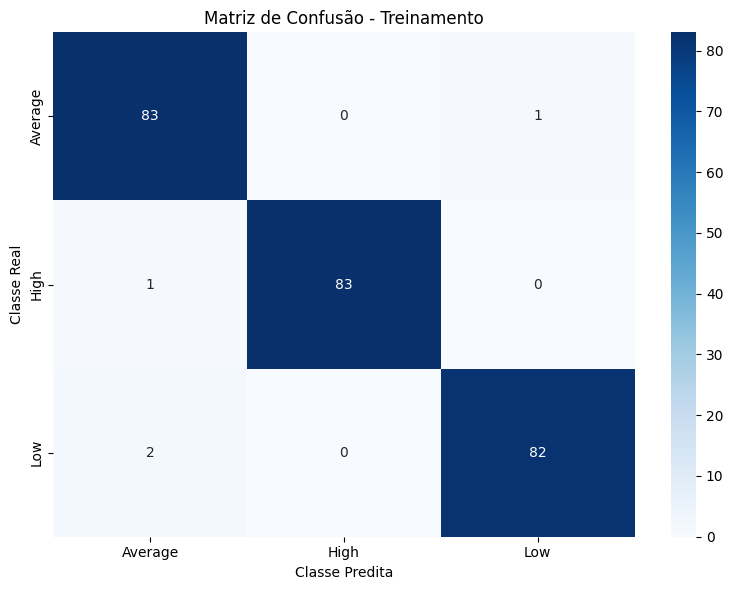

In [45]:
# Plotando a matriz de confusão para o conjunto de treinamento
plot_confusion_matrix(y_train, y_pred_train, labels=np.unique(y_train), title='Matriz de Confusão - Treinamento')

### Avaliação obtida pelas previsões da base de treino


Como podemos observar, a acurácia e o recall apresentaram um resultado de 0.98. O que significa que o modelo está fazendo predições corretas em 98% dos casos, e o recall indica que o modelo está corretamente identificando 98% dos exemplos de relação positiva de atribuição de clientes em seu score de crédito.


A matriz de confusão de treino, permite evidenciar essa indicação onde apresenta uma quantidade extremamente efetiva de acertos em cada avaliação.


Por se tratar de uma base pequena, não podemos descartar problemas de overfitting, onde o modelo aprende muito bem os dados de treino e por sua vez não consegue identificar padrões gerais relevantes.


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [46]:
#seu código aqui

# Fazendo previsões para os dados de teste
y_pred_test = gnb.predict(X_test)

#Calculando a acurácia
accuraracy_test = accuracy_score(y_test, y_pred_test)

# Calculando o recall
recall_test = recall_score(y_test, y_pred_test, average='macro')

print(f"Acurácia no conjunto de treinamento: {accuraracy_test:.2f}")
print(f"Recall no conjunto de treinamento: {recall_test:.2f}")

Acurácia no conjunto de treinamento: 0.98
Recall no conjunto de treinamento: 0.94


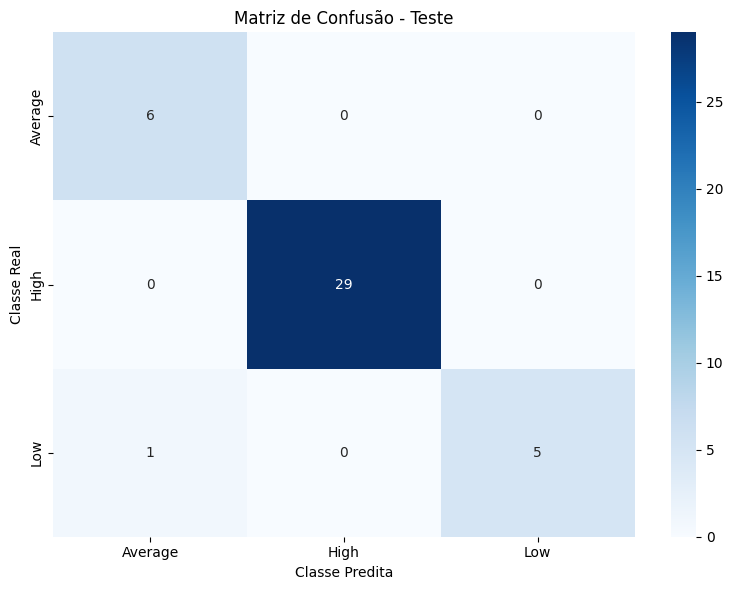

In [47]:
# Plotando a matriz de confusão para o conjunto de teste
plot_confusion_matrix(y_test, y_pred_test, labels=np.unique(y_test), title='Matriz de Confusão - Teste')

### Avaliação obtida pelas previsões da base de teste

Na avaliação dos dados de teste, a acurácia e o recall apresentaram um resultado muito próximo. O que significa que o modelo está fazendo predições corretas em 98% dos casos, e o recall indica que o modelo está corretamente identificando 94% dos exemplos de relação positiva de atribuição de clientes em seu score de crédito.

A matriz de confusão de treino, consegue expor de forma clara as atribuições de vínculo de avaliação de cada item do ambiente de teste.(Que é menor que a base de treino)

Conforme orientado na avaliação dos dados obtidos na base de treino, overfitting pode ser um problema na predição na base de teste.


# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

Nesta atividade, desenvolvemos um modelo preditivo para classificar o score de crédito dos clientes utilizando o algoritmo Naive Bayes. O objetivo principal foi aplicar técnicas de aprendizado de máquina para prever, de forma probabilística, o risco de inadimplência. O Naive Bayes permite analisar rapidamente múltiplas variáveis e identificar padrões relevantes para a concessão de crédito. Assim, ajudamos instituições financeiras a tomar decisões mais seguras e eficientes.